#  Olist Sales Analysis
### End-to-end sales data analysis — Brazilian E-Commerce

---

**Goal:** Analyze sales performance, customer behavior, delivery logistics 
and product trends using the Olist dataset — with machine learning predictions.

| | |
|---|---|
| **Dataset** | Olist Brazilian E-Commerce (Kaggle) |
| **Language** | Python 3 |
| **Libraries** | pandas, matplotlib, scikit-learn, kagglehub |

---

##  Project Structure

| Step | Section |
|------|---------|
| 1 | Data Collection & Loading |
| 2 | Data Cleaning & Validation |
| 3 | Feature Engineering |
| 4 | KPI Analysis |
| 5 | RFM & Cohort Analysis |
| 6 | Delivery vs Satisfaction Correlation |
| 7 | Visualizations & Dashboard |
| 8 | Machine Learning |
| 9 | Insights & Business Recommendations |

In [22]:
# ==========================================================
# IMPORTS
# ==========================================================

# File management

import os
import shutil
# Data manipulation
import pandas as pd 
import numpy as np 
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Dataset download
import kagglehub
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")


In [2]:
# ==========================================================
# PATHS
# ==========================================================

# Use current directory — works on any machine
project_path = os.getcwd()

# Define sub-folders
raw_path     = os.path.join(project_path, "data", "raw")
cleaned_path = os.path.join(project_path, "data", "cleaned")
gold_path    = os.path.join(project_path, "data", "gold")

# Create folders if they don't exist
os.makedirs(raw_path,     exist_ok=True)
os.makedirs(cleaned_path, exist_ok=True)
os.makedirs(gold_path,    exist_ok=True)

# Output / Ausgabe
print(f"Project path   : {project_path}")
print(f"Raw data path  : {raw_path}")
print(f"Cleaned path   : {cleaned_path}")
print(f"Gold path      : {gold_path}")


Project path   : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis
Raw data path  : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/raw
Cleaned path   : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/cleaned
Gold path      : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/gold


In [3]:
# ==========================================================
# DOWNLOAD DATASET FROM KAGGLE
# ==========================================================

# Download dataset automatically from Kaggle
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Copy all CSV files to our raw folde
for file in os.listdir(dataset_path):
    source_file = os.path.join(dataset_path, file)
    target_file = os.path.join (raw_path, file)
    shutil.copy(source_file, target_file)

# Output / Ausgabe
print(" Dataset downloaded successfully")
print(f"\n📁 Files copied to : {raw_path}")



 Dataset downloaded successfully

📁 Files copied to : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/raw


In [4]:
# ==========================================================
# LOAD ALL CSV FILES
# ==========================================================

# Load each CSV file into a dictionary of DataFrames
files = [f for f in os.listdir(raw_path) if f.endswith(".csv")]

dataframes = {}

for file in files:
    file_path = os.path.join(raw_path, file)
    df_name = (file
               .replace(".csv", "")
               .replace("olist_", "")
               .replace("_dataset", ""))
    dataframes[df_name] = pd.read_csv(file_path)

# Output / Ausgabe
print("Tables loaded successfully")
#print("Tabellen erfolgreich geladen")
print(f"\n{'Table':<45} {'Rows':<10} {'Columns'}")
print("-" * 65)
for name, df in dataframes.items():
    print(f"{name:<45} {df.shape[0]:<10} {df.shape[1]}")

Tables loaded successfully

Table                                         Rows       Columns
-----------------------------------------------------------------
sellers                                       3095       4
product_category_name_translation             71         2
orders                                        99441      8
order_items                                   112650     7
customers                                     99441      5
geolocation                                   1000163    5
order_payments                                103886     5
order_reviews                                 99224      7
products                                      32951      9


##  Dataset Overview

The Olist dataset contains **9 tables** representing the full e-commerce pipeline — from the customer order to the seller delivery.

| Table | Description | Rows |
|-------|-------------|------|
| `orders` | Master order table | 99,441 |
| `order_items` | Products inside each order | 112,650 |
| `customers` | Customer information | 99,441 |
| `sellers` | Seller information | 3,095 |
| `products` | Product catalog | 32,951 |
| `order_payments` | Payment details | 103,886 |
| `order_reviews` | Customer reviews & scores | 99,224 |
| `product_category_name_translation` | Category names in English | 71 |
| `geolocation` | Brazilian zip code coordinates | 1,000,163 |

---

>  **Key insight:** `order_items` has more rows than `orders` — 
> meaning many orders contain **multiple products**.

---

##  Data Understanding

Before cleaning, we explore each table to understand:
- Data types
- Missing values
- Duplicates
- Key relationships between tables

In [5]:
# ==========================================================
# DATA UNDERSTANDING
# ==========================================================

for name, df in dataframes.items():
    print(f"\n{'=' * 60}")
    print(f"  TABLE : {name.upper()}")
    print(f"{'=' * 60}")
    print(f"  Shape         : {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Duplicates    : {df.duplicated().sum()}")
    print(f"  ID columns    : {[col for col in df.columns if 'id' in col.lower()]}")
    print(f"\n  Sample data:")
    print(df.head(2).to_string())


  TABLE : SELLERS
  Shape         : 3095 rows x 4 columns
  Missing values: 0
  Duplicates    : 0
  ID columns    : ['seller_id']

  Sample data:
                          seller_id  seller_zip_code_prefix seller_city seller_state
0  3442f8959a84dea7ee197c632cb2df15                   13023    campinas           SP
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844  mogi guacu           SP

  TABLE : PRODUCT_CATEGORY_NAME_TRANSLATION
  Shape         : 71 rows x 2 columns
  Missing values: 0
  Duplicates    : 0
  ID columns    : []

  Sample data:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories

  TABLE : ORDERS
  Shape         : 99441 rows x 8 columns
  Missing values: 4908
  Duplicates    : 0
  ID columns    : ['order_id', 'customer_id']

  Sample data:
                           order_id                       customer_id order_status order_purchase_timestam

### Data Quality Summary

| Table | Rows | Missing Values | Duplicates |
|-------|------|----------------|------------|
| sellers | 3,095 | 0 | 0 |
| orders | 99,441 | 4,908 | 0 |
| order_items | 112,650 | 0 | 0 |
| customers | 99,441 | 0 | 0 |
| geolocation | 1,000,163 | 0 | 261,831 |
| order_payments | 103,886 | 0 | 0 |
| order_reviews | 99,224 | 145,903 | 0 |
| products | 32,951 | 2,448 | 0 |
| product_category_name_translation | 71 | 0 | 0 |

**Key observations:**
- `order_reviews` has the most missing values — comment fields are often left empty
- `geolocation` has 261,831 duplicates — will be excluded from joins
- `orders` missing values — some deliveries not yet completed
- Date columns are stored as **strings** → need conversion

##  Data Cleaning

We fix the 3 main issues identified above:
1. **Date columns** stored as strings → convert to `datetime`
2. **Missing values** → fill with appropriate values
3. **Duplicates** in geolocation → drop

In [6]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# -------------------------
# 1. Convert date columns
# -------------------------
df_orders = dataframes ["orders"]
orders_date_cols =[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in orders_date_cols :
    df_orders[col]= pd.to_datetime(df_orders[col])

df_items = dataframes["order_items"]
df_items["shipping_limit_date"] = pd.to_datetime (df_items["shipping_limit_date"])

df_reviews = dataframes["order_reviews"]
df_reviews["review_creation_date"]    = pd.to_datetime(df_reviews["review_creation_date"])
df_reviews["review_answer_timestamp"] = pd.to_datetime(df_reviews["review_answer_timestamp"])

# -------------------------
# 2. Handle missing values
# -------------------------
df_products = dataframes["products"]
df_products["product_category_name"] = df_products["product_category_name"].fillna("unknown")

product_numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]
df_products[product_numeric_cols] = df_products[product_numeric_cols].fillna(0)

df_reviews["review_comment_title"]   = df_reviews["review_comment_title"].fillna("no_review")
df_reviews["review_comment_message"] = df_reviews["review_comment_message"].fillna("no_review")

# -------------------------
# 3. Remove geolocation duplicates
# -------------------------
dataframes["geolocation"] = dataframes["geolocation"].drop_duplicates()

# -------------------------
# 4. Verify cleaning results
# -------------------------
print(f"{'Table':<45} {'Missing After':<15} {'Duplicates After'}")
print("-" * 75)
for name, df in dataframes.items():
    print(f"{name:<45} {df.isnull().sum().sum():<15} {df.duplicated().sum()}")

Table                                         Missing After   Duplicates After
---------------------------------------------------------------------------
sellers                                       0               0
product_category_name_translation             0               0
orders                                        4908            0
order_items                                   0               0
customers                                     0               0
geolocation                                   0               0
order_payments                                0               0
order_reviews                                 0               0
products                                      0               0


**Note:** The 4,908 remaining missing values in `orders` are expected —
> they correspond to orders that were **not yet delivered** at the time 
> of data collection. These will be handled during feature engineering.

## Data Validation

We verify the integrity of our data before modeling:
1. **Primary keys** — each ID must be unique
2. **Relationships** — foreign keys must match between tables

In [7]:
# ==========================================================
# DATA VALIDATION
# ==========================================================

# -------------------------
# 1. Primary key checks
# -------------------------
primary_keys = {
    "orders"    : ("order_id",    dataframes["orders"]),
    "customers" : ("customer_id", dataframes["customers"]),
    "products"  : ("product_id",  dataframes["products"]),
    "sellers"   : ("seller_id",   dataframes["sellers"])
}

print("PRIMARY KEY VALIDATION")
print("-" * 55)
print(f"{'Table':<15} {'Unique IDs':<15} {'Total Rows':<15} {'Valid?'}")
print("-" * 55)

for table, (key, df) in primary_keys.items():
    unique = df[key].nunique()
    total  = df.shape[0]
    valid  = " Yes" if unique == total else " No"
    print(f"{table:<15} {unique:<15} {total:<15} {valid}")

# -------------------------
# 2. Relationship checks
# -------------------------
print("\nRELATIONSHIP VALIDATION")
print("-" * 55)

checks = [
    ("order_items → orders",   "order_id",   "order_items",  "orders"),
    ("order_items → products", "product_id", "order_items",  "products"),
    ("order_items → sellers",  "seller_id",  "order_items",  "sellers"),
    ("order_reviews → orders", "order_id",   "order_reviews","orders"),
    ("order_payments → orders","order_id",   "order_payments","orders"),
]

print(f"{'Relationship':<30} {'Missing':<10} {'Valid?'}")
print("-" * 55)

for label, key, left, right in checks:
    missing = (~dataframes[left][key].isin(dataframes[right][key])).sum()
    valid   = " Yes" if missing == 0 else f" {missing}"
    print(f"{label:<30} {missing:<10} {valid}")

PRIMARY KEY VALIDATION
-------------------------------------------------------
Table           Unique IDs      Total Rows      Valid?
-------------------------------------------------------
orders          99441           99441            Yes
customers       99441           99441            Yes
products        32951           32951            Yes
sellers         3095            3095             Yes

RELATIONSHIP VALIDATION
-------------------------------------------------------
Relationship                   Missing    Valid?
-------------------------------------------------------
order_items → orders           0           Yes
order_items → products         0           Yes
order_items → sellers          0           Yes
order_reviews → orders         0           Yes
order_payments → orders        0           Yes


###  Validation Results

All primary keys and relationships are **100% valid** — 
the dataset is ready for modeling.

> **Note:** `order_items`, `order_payments` and `order_reviews` 
> are intentionally excluded from primary key validation — 
> they are **transactional tables** where multiple rows per order are expected.

In [8]:
## Save Cleaned Tables
'''
We save all cleaned tables to the `data/cleaned` folder
for future use — excluding `geolocation` which is too large
and not needed for our analysis.
'''
# ==========================================================
# SAVE CLEANED TABLES
# ==========================================================

saved = []
skipped = []

for name, df in dataframes.items():
    # Skip geolocation — too large and not used in joins
    if name == "geolocation":
        skipped.append(name)
        continue

    file_path = os.path.join(cleaned_path, f"{name}_cleaned.csv")
    df.to_csv(file_path, index=False)
    saved.append((name, df.shape))

# Output / Ausgabe
print(f"{'Table':<45} {'Rows':<10} {'Columns'}")
print("-" * 65)
for name, shape in saved:
    print(f"{name:<45} {shape[0]:<10} {shape[1]}")

print(f"\n {len(saved)} tables saved to : {cleaned_path}")
print(f"  Skipped : {skipped}")
#print(f"\n {len(saved)} Tabellen gespeichert")
#print(f" Übersprungen : {skipped}")


Table                                         Rows       Columns
-----------------------------------------------------------------
sellers                                       3095       4
product_category_name_translation             71         2
orders                                        99441      8
order_items                                   112650     7
customers                                     99441      5
order_payments                                103886     5
order_reviews                                 99224      7
products                                      32951      9

 8 tables saved to : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/cleaned
  Skipped : ['geolocation']


##  Data Modeling — Joins

We build one **master table** `df_sales` by joining all relevant tables.
This single table will be used for all analysis and machine learning.

### Join Strategy

| Step | Join | Key |
|------|------|-----|
| Base | `order_items` | — |
| 1 | + `orders` | `order_id` |
| 2 | + `products` | `product_id` |
| 3 | + `category translation` | `product_category_name` |
| 4 | + `customers` | `customer_id` |
| 5 | + `sellers` | `seller_id` |
| 6 | + `payments` (aggregated) | `order_id` |
| 7 | + `reviews` (aggregated) | `order_id` |

###  Why aggregate payments and reviews before joining?

`order_payments` and `order_reviews` have **multiple rows per order** :

| order_id | payment_type | payment_value |
|----------|-------------|---------------|
| order_1 | credit_card | 50.00 |
| order_1 | voucher | 10.00 |

A direct join would **duplicate rows** in our master table.
So we first aggregate them into **one row per order** :
- `payments` → sum of `payment_value` + max of `payment_installments`
- `reviews` → mean of `review_score`

In [9]:
# ==========================================================
# DATA MODELING / JOINS
# ==========================================================

# Start with order_items as the base table
df_sales = dataframes["order_items"].copy()

# -------------------------
# Simple joins
# -------------------------
simple_joins = [
    ("orders",                              "order_id"),
    ("products",                            "product_id"),
    ("product_category_name_translation",   "product_category_name"),
    ("customers",                           "customer_id"),
    ("sellers",                             "seller_id")
]
print(f"{'Join':<45} {'Rows Before':<15} {'Rows After'}")
print("-" * 75)

for table_name, join_key in simple_joins:
    before = df_sales.shape[0]
    df_sales = df_sales.merge(
        dataframes[table_name],
        on =join_key,
        how = "left"
    )
    after =df_sales.shape[0]
    print(f"+ {table_name:<43} {before:<15} {after}")

# -------------------------
# Aggregate payments before join
# -------------------------
payments_agg = dataframes["order_payments"].groupby("order_id").agg(
    payment_value        = ("payment_value", "sum"),
    payment_installments = ("payment_installments", "max")
).reset_index()

before = df_sales.shape[0]
df_sales = df_sales.merge(payments_agg, on="order_id", how="left")
print(f"+ {'payments (aggregated)':<43} {before:<15} {df_sales.shape[0]}")

# -------------------------
# Aggregate reviews before join
# -------------------------
reviews_agg = dataframes["order_reviews"].groupby("order_id").agg(
    review_score = ("review_score", "mean")
).reset_index()

before = df_sales.shape[0]
df_sales = df_sales.merge(reviews_agg, on="order_id", how="left")
print(f"+ {'reviews (aggregated)':<43} {before:<15} {df_sales.shape[0]}")

# Output / Ausgabe
print(f"\n Master table shape : {df_sales.shape}")
#print(f" Mastertabelle Form : {df_sales.shape}")

Join                                          Rows Before     Rows After
---------------------------------------------------------------------------
+ orders                                      112650          112650
+ products                                    112650          112650
+ product_category_name_translation           112650          112650
+ customers                                   112650          112650
+ sellers                                     112650          112650
+ payments (aggregated)                       112650          112650
+ reviews (aggregated)                        112650          112650

 Master table shape : (112650, 33)


All joins completed successfully — **no row duplication**.

| Metric | Value |
|--------|-------|
| Final rows | 112,650 |
| Final columns | 33 |
| Data loss | 0% |

> **Key insight:** The master table `df_sales` preserves exactly 
> the same number of rows as `order_items` — confirming that all 
> foreign keys matched perfectly across every table.

## Feature Engineering

We create new columns from existing data to enrich our analysis.

| Feature               | Description                          | Source                              |
|----------------------|--------------------------------------|-------------------------------------|
| `revenue`            | price + freight                      | `price` + `freight_value`           |
| `year`, `month`, `quarter`, `week` | Date breakdown        | `order_purchase_timestamp`          |
| `year_month`         | Period for time series               | `order_purchase_timestamp`          |
| `weekday`            | Day of week                          | `order_purchase_timestamp`          |
| `season`             | Brazilian season                     | `month`                             |
| `delivery_time_days` | Actual delivery duration             | delivered - purchased               |
| `delivery_delay_days`| Delay vs estimated date              | delivered - estimated               |
| `is_late`            | 1 if order was late                  | `delivery_delay_days`               |
| `total_orders`       | Orders per customer                  | aggregation                         |
| `total_revenue`      | Revenue per customer                 | aggregation                         |
| `is_repeat_customer` | 1 if more than 1 order               | `total_orders`                      |
| `items_per_order`    | Items in each order                  | aggregation                         |
| `order_total_value`  | Total value per order                | aggregation                         |
| `is_high_value_order`| 1 if above median value              | `order_total_value`                 |
| `freight_ratio`      | Freight share of revenue             | `freight_value / revenue`           |
| `positive_review`    | 1 if review score >= 4               | `review_score`                      |
| `customer_segment`   | Low / Medium / High value            | `total_revenue` quartiles           |

In [10]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# -------------------------
# 1. Revenue
# -------------------------
df_sales["revenue"] = df_sales["price"] + df_sales["freight_value"]

# -------------------------
# 2. Date features
# -------------------------
df_sales["order_purchase_timestamp"]      = pd.to_datetime(df_sales["order_purchase_timestamp"])
df_sales["order_delivered_customer_date"] = pd.to_datetime(df_sales["order_delivered_customer_date"])
df_sales["order_estimated_delivery_date"] = pd.to_datetime(df_sales["order_estimated_delivery_date"])

df_sales["year"]       = df_sales["order_purchase_timestamp"].dt.year
df_sales["month"]      = df_sales["order_purchase_timestamp"].dt.month
df_sales["day"]        = df_sales["order_purchase_timestamp"].dt.day
df_sales["year_month"] = df_sales["order_purchase_timestamp"].dt.to_period("M").astype(str)
df_sales["quarter"]    = df_sales["order_purchase_timestamp"].dt.quarter
df_sales["week"]       = df_sales["order_purchase_timestamp"].dt.isocalendar().week.astype(int)
df_sales["weekday"]    = df_sales["order_purchase_timestamp"].dt.day_name()

# -------------------------
# 3. Season (Brazilian calendar)
# -------------------------
df_sales["season"] = df_sales["month"].map({
    12: "Summer", 1: "Summer",  2: "Summer",
    3:  "Autumn", 4: "Autumn",  5: "Autumn",
    6:  "Winter", 7: "Winter",  8: "Winter",
    9:  "Spring", 10: "Spring", 11: "Spring"
})

# -------------------------
# 4. Customer features
# -------------------------
customer_agg = df_sales.groupby("customer_unique_id").agg(
    total_orders  = ("order_id", "nunique"),
    total_revenue = ("revenue",  "sum")
).reset_index()

df_sales = df_sales.merge(customer_agg, on="customer_unique_id", how="left")

df_sales["is_repeat_customer"] = (df_sales["total_orders"] > 1).astype(int)

# -------------------------
# 5. Order features
# -------------------------
order_agg = df_sales.groupby("order_id").agg(
    items_per_order   = ("order_item_id", "count"),
    order_total_value = ("revenue",       "sum")
).reset_index()

df_sales = df_sales.merge(order_agg, on="order_id", how="left")

df_sales["is_high_value_order"] = (
    df_sales["order_total_value"] > df_sales["order_total_value"].median()
).astype(int)

# -------------------------
# 6. Delivery metrics
# -------------------------
df_sales["delivery_time_days"] = (
    df_sales["order_delivered_customer_date"] -
    df_sales["order_purchase_timestamp"]
).dt.days

df_sales["delivery_delay_days"] = (
    df_sales["order_delivered_customer_date"] -
    df_sales["order_estimated_delivery_date"]
).dt.days

df_sales["is_late"] = (df_sales["delivery_delay_days"] > 0).astype(int)

# -------------------------
# 7. Freight ratio
# -------------------------
df_sales["freight_ratio"] = df_sales["freight_value"] / df_sales["revenue"]

# -------------------------
# 8. Review sentiment
# -------------------------
df_sales["positive_review"] = (df_sales["review_score"] >= 4).astype(int)

# -------------------------
# 9. Customer segmentation
# -------------------------
df_sales["customer_segment"] = pd.qcut(
    df_sales["total_revenue"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Output / Ausgabe
print(f" Total columns after feature engineering : {df_sales.shape[1]}")
#print(f" Gesamtspalten nach Feature Engineering  : {df_sales.shape[1]}")
print(f"\n{'Feature':<25} {'Type':<15} {'Non-null Count'}")
print("-" * 60)
all_features = [
    "revenue", "year", "month", "quarter", "week",
    "weekday", "year_month", "season",
    "delivery_time_days", "delivery_delay_days", "is_late",
    "total_orders", "total_revenue", "is_repeat_customer",
    "items_per_order", "order_total_value", "is_high_value_order",
    "freight_ratio", "positive_review", "customer_segment"
]
for col in all_features:
    print(f"{col:<25} {str(df_sales[col].dtype):<15} {df_sales[col].notnull().sum()}")

 Total columns after feature engineering : 54

Feature                   Type            Non-null Count
------------------------------------------------------------
revenue                   float64         112650
year                      int32           112650
month                     int32           112650
quarter                   int32           112650
week                      int64           112650
weekday                   str             112650
year_month                str             112650
season                    str             112650
delivery_time_days        float64         110196
delivery_delay_days       float64         110196
is_late                   int64           112650
total_orders              int64           112650
total_revenue             float64         112650
is_repeat_customer        int64           112650
items_per_order           int64           112650
order_total_value         float64         112650
is_high_value_order       int64           112650
fr

## KPI Analysis

Key Performance Indicators give a global view of the business health.

| KPI | Description |
|-----|-------------|
| `Total Revenue` | Sum of all sales |
| `Total Orders` | Number of unique orders |
| `Avg Order Value` | Average revenue per order |
| `Total Customers` | Number of unique customers |
| `Avg Delivery Time` | Average days to deliver |
| `Delay Rate` | % of orders delivered late |
| `Repeat Customer Rate` | % of customers who ordered more than once |
| `Avg Review Score` | Average customer satisfaction |

In [11]:
# ==========================================================
# KPI ANALYSIS
# ==========================================================

# -------------------------
# Calculate KPIs
# -------------------------
total_revenue        = df_sales["revenue"].sum()
total_orders         = df_sales["order_id"].nunique()
avg_order_value      = df_sales["order_total_value"].mean()
total_customers      = df_sales["customer_unique_id"].nunique()
avg_delivery_time    = df_sales["delivery_time_days"].mean()
delay_rate           = df_sales["is_late"].mean()
repeat_customer_rate = df_sales["is_repeat_customer"].mean()
avg_review_score     = df_sales["review_score"].mean()

# -------------------------
# Display KPIs
# -------------------------
print("=" * 55)
print("         BUSINESS KPI SUMMARY")
print("=" * 55)
print(f"  💰 Total Revenue          : R$ {total_revenue:>12,.2f}")
print(f"  🛒 Total Orders           : {total_orders:>12,}")
print(f"  💳 Avg Order Value        : R$ {avg_order_value:>12,.2f}")
print(f"  👥 Total Customers        : {total_customers:>12,}")
print(f"  🚚 Avg Delivery Time      : {avg_delivery_time:>11.1f} days")
print(f"    Delay Rate             : {delay_rate*100:>11.1f} %")
print(f"  🔁 Repeat Customer Rate   : {repeat_customer_rate*100:>11.1f} %")
print(f"  ⭐ Avg Review Score       : {avg_review_score:>11.2f} / 5")
print("=" * 55)

# -------------------------
# KPIs by year
# -------------------------
print("\nKPIs BY YEAR")
print("-" * 55)
yearly_kpis = (
    df_sales.groupby("year")
    .agg(
        revenue       = ("revenue",    "sum"),
        orders        = ("order_id",   "nunique"),
        customers     = ("customer_unique_id", "nunique"),
        avg_review    = ("review_score", "mean"),
        delay_rate    = ("is_late",    "mean")
    )
    .reset_index()
)

print(f"{'Year':<8} {'Revenue':>12} {'Orders':>10} {'Customers':>12} {'Avg Review':>12} {'Delay Rate':>12}")
print("-" * 70)
for _, row in yearly_kpis.iterrows():
    print(f"{int(row.year):<8} R${row.revenue:>11,.0f} {int(row.orders):>10,} {int(row.customers):>12,} {row.avg_review:>12.2f} {row.delay_rate*100:>11.1f}%")

         BUSINESS KPI SUMMARY
  💰 Total Revenue          : R$ 15,843,553.24
  🛒 Total Orders           :       98,666
  💳 Avg Order Value        : R$       180.24
  👥 Total Customers        :       95,420
  🚚 Avg Delivery Time      :        12.0 days
    Delay Rate             :         6.4 %
  🔁 Repeat Customer Rate   :         6.6 %
  ⭐ Avg Review Score       :        4.03 / 5

KPIs BY YEAR
-------------------------------------------------------
Year          Revenue     Orders    Customers   Avg Review   Delay Rate
----------------------------------------------------------------------
2016     R$     57,183        312          309         3.56         1.4%
2017     R$  7,142,672     44,579       43,225         4.05         5.4%
2018     R$  8,643,698     53,775       52,565         4.02         7.3%


>  **Key insights:**
> - Revenue grew **+21% from 2017 to 2018** — strong business growth
> - Delay rate is **increasing year over year** — logistics needs attention
> - Repeat customer rate of **6.6% is very low** — customer retention 
> is the biggest challenge for Olist

## 👥 RFM Analysis

RFM is a proven marketing framework to segment customers 
based on their purchasing behavior.

| Dimension | Description | Question |
|-----------|-------------|----------|
| **R — Recency** | How recently did the customer order? | Days since last order |
| **F — Frequency** | How often does the customer order? | Number of orders |
| **M — Monetary** | How much does the customer spend? | Total revenue |

### Scoring
Each customer receives a score from **1 to 4** per dimension:
- **4** = Best behavior
- **1** = Worst behavior

### Segments
| Segment | RFM Score | Description |
|---------|-----------|-------------|
| 🏆 Champions | R4 F4 M4 | Best customers |
| 💛 Loyal | F3-4 | Order frequently |
| 🔄 Potential Loyalist | R3-4 F1-2 | Recent but few orders |
| 😴 At Risk | R1-2 F3-4 | Used to buy often, now inactive |
| 💀 Lost | R1 F1 M1 | Lowest scores |

In [12]:
# ==========================================================
# RFM ANALYSIS
# ==========================================================

# Reference date — day after last order in dataset
reference_date = df_sales["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# -------------------------
# 1. Calculate R, F, M
# -------------------------
rfm = df_sales.groupby("customer_unique_id").agg(
    recency   = ("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    frequency = ("order_id",                 "nunique"),
    monetary  = ("revenue",                  "sum")
).reset_index()

# -------------------------
# 2. Score each dimension (1 to 4)
# -------------------------

# Recency — lower is better (more recent = higher score)
rfm["r_score"] = pd.qcut(rfm["recency"],   q=4, labels=[4, 3, 2, 1])

# Frequency — higher is better
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])

# Monetary — higher is better
rfm["m_score"] = pd.qcut(rfm["monetary"],  q=4, labels=[1, 2, 3, 4])

# -------------------------
# 3. Combined RFM score
# -------------------------
rfm["rfm_score"] = (
    rfm["r_score"].astype(int) +
    rfm["f_score"].astype(int) +
    rfm["m_score"].astype(int)
)

# -------------------------
# 4. Customer segments
# -------------------------
def rfm_segment(row):
    r = int(row["r_score"])
    f = int(row["f_score"])
    m = int(row["m_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif f >= 3:
        return "Loyal"
    elif r >= 3 and f <= 2:
        return "Potential Loyalist"
    elif r <= 2 and f >= 3:
        return "At Risk"
    else:
        return "Lost"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)

# -------------------------
# 5. Output
# -------------------------
print(f" RFM table shape : {rfm.shape}")
print(f"\nRFM SEGMENT DISTRIBUTION")
print("-" * 50)

segment_counts = rfm["segment"].value_counts()
for segment, count in segment_counts.items():
    pct = count / len(rfm) * 100
    print(f"  {segment:<30} {count:>6,}  ({pct:.1f}%)")

print(f"\nRFM STATISTICS")
print("-" * 50)
print(rfm[["recency", "frequency", "monetary", "rfm_score"]].describe().round(2))

 RFM table shape : (95420, 9)

RFM SEGMENT DISTRIBUTION
--------------------------------------------------
  Loyal                          45,883  (48.1%)
  Lost                           23,875  (25.0%)
  Potential Loyalist             23,835  (25.0%)
  Champions                       1,827  (1.9%)

RFM STATISTICS
--------------------------------------------------
       recency  frequency  monetary  rfm_score
count 95420.00   95420.00  95420.00   95420.00
mean    243.60       1.03    166.04       7.50
std     153.16       0.21    228.32       1.97
min       1.00       1.00      9.59       3.00
25%     119.00       1.00     63.10       6.00
50%     224.00       1.00    107.94       7.00
75%     353.00       1.00    183.22       9.00
max     729.00      16.00  13664.08      12.00


###  RFM Results

| Segment | Customers | % | Action |
|---------|-----------|---|--------|
| 🏆 Champions | 1,827 | 1.9% | Reward & retain — they drive the most value |
| 💛 Loyal | 45,883 | 48.1% | Upsell & cross-sell opportunities |
| 🔄 Potential Loyalist | 23,835 | 25.0% | Nurture with targeted campaigns |
| 💀 Lost | 23,875 | 25.0% | Re-engagement campaigns needed |

###  RFM Statistics

| Metric | Recency | Frequency | Monetary |
|--------|---------|-----------|----------|
| Mean | 244 days | 1.03 orders | R$ 166 |
| Max | 729 days | 16 orders | R$ 13,664 |

> **Key insights:**
> - **48.1% of customers are Loyal** — good base to work with
> - **25% are Lost** — re-engagement campaigns are critical
> - **Average frequency of 1.03** confirms the low repeat purchase rate
> seen in KPIs — most customers order **only once**
> - **Champions represent only 1.9%** but are likely the 
> highest revenue contributors

## Cohort Analysis

A cohort is a group of customers who made their **first purchase 
in the same month**.

We track how many of them come back in the following months.

### Why is this important?
- Measures **customer retention** over time
- Identifies **when customers churn**
- Helps evaluate the impact of **marketing campaigns**

>  Each cell shows the **% of customers retained** 
> compared to the cohort's first month.

In [13]:
# ==========================================================
# COHORT ANALYSIS
# ==========================================================

# -------------------------
# 1. Get first purchase date per customer
# -------------------------
df_cohort = df_sales[["customer_unique_id", "order_purchase_timestamp"]].copy()

df_cohort["order_month"] = df_cohort["order_purchase_timestamp"].dt.to_period("M")

first_purchase = (
    df_cohort.groupby("customer_unique_id")["order_month"]
    .min()
    .reset_index()
    .rename(columns={"order_month": "cohort_month"})
)

df_cohort = df_cohort.merge(first_purchase, on="customer_unique_id", how="left")

# -------------------------
# 2. Calculate cohort index (months since first purchase)
# -------------------------
df_cohort["cohort_index"] = (
    (df_cohort["order_month"] - df_cohort["cohort_month"])
    .apply(lambda x: x.n)
)

# -------------------------
# 3. Build cohort table
# -------------------------
cohort_table = (
    df_cohort.groupby(["cohort_month", "cohort_index"])["customer_unique_id"]
    .nunique()
    .unstack()
)

# -------------------------
# 4. Retention rate
# -------------------------
cohort_size    = cohort_table.iloc[:, 0]
retention_table = cohort_table.divide(cohort_size, axis=0).round(3) * 100

# -------------------------
# 5. Output
# -------------------------
print(" Cohort table built successfully")
print(f" Shape : {retention_table.shape}")
print(f"\nRETENTION RATE (%) — First 6 months")
print("-" * 70)
print(retention_table.iloc[:10, :6].to_string())

 Cohort table built successfully
 Shape : (23, 20)

RETENTION RATE (%) — First 6 months
----------------------------------------------------------------------
cohort_index      0      1    2    3    4    5
cohort_month                                  
2016-09      100.00    NaN  NaN  NaN  NaN  NaN
2016-10      100.00    NaN  NaN  NaN  NaN  NaN
2016-12      100.00 100.00  NaN  NaN  NaN  NaN
2017-01      100.00   0.40 0.30 0.10 0.40 0.10
2017-02      100.00   0.20 0.30 0.10 0.40 0.10
2017-03      100.00   0.50 0.30 0.40 0.30 0.20
2017-04      100.00   0.60 0.20 0.20 0.30 0.30
2017-05      100.00   0.50 0.50 0.40 0.30 0.30
2017-06      100.00   0.50 0.40 0.40 0.30 0.40
2017-07      100.00   0.50 0.40 0.20 0.30 0.20


>  **Key insights:**
> - Retention drops to **less than 1% after the first month** — 
> the vast majority of customers never come back
> - This confirms the KPI finding : **repeat customer rate of 6.6%**
> - Olist's business is driven by **new customer acquisition**, 
> not retention
> - **Recommendation :** Implement loyalty programs and 
> post-purchase email campaigns to improve retention

## Delivery vs Satisfaction Correlation

We analyze the relationship between **delivery performance** 
and **customer satisfaction** (review score).

### Hypothesis
> The longer the delivery time and the higher the delay, 
> the lower the customer review score.

### What we measure
| Analysis | Description |
|----------|-------------|
| Correlation | Statistical link between delivery time and review score |
| Late vs On-time | Average review score comparison |
| Delivery time buckets | Review score by delivery speed |
| Region analysis | Delivery time vs satisfaction by state |

In [14]:
# ==========================================================
# DELIVERY VS SATISFACTION CORRELATION
# ==========================================================

# Keep only delivered orders with valid data
df_delivery = df_sales[
    (df_sales["delivery_time_days"].notna()) &
    (df_sales["review_score"].notna()) &
    (df_sales["delivery_delay_days"].notna())
].copy()

# -------------------------
# 1. Correlation matrix
# -------------------------
corr_cols = ["delivery_time_days", "delivery_delay_days", 
             "review_score", "freight_value", "price"]

corr_matrix = df_delivery[corr_cols].corr().round(3)

print("CORRELATION MATRIX")
print("-" * 60)
print(corr_matrix.to_string())

# -------------------------
# 2. Late vs On-time review scores
# -------------------------
late_review    = df_delivery[df_delivery["is_late"] == 1]["review_score"].mean()
ontime_review  = df_delivery[df_delivery["is_late"] == 0]["review_score"].mean()

print(f"\nREVIEW SCORE : LATE vs ON-TIME")
print("-" * 40)
print(f"    Late orders    : {late_review:.2f} / 5")
print(f"   On-time orders  : {ontime_review:.2f} / 5")
print(f"   Difference      : {ontime_review - late_review:.2f} points")

# -------------------------
# 3. Review score by delivery time bucket
# -------------------------
df_delivery["delivery_bucket"] = pd.cut(
    df_delivery["delivery_time_days"],
    bins=[0, 7, 14, 21, 30, 100],
    labels=["0-7 days", "8-14 days", "15-21 days", "22-30 days", "30+ days"]
)

bucket_review = (
    df_delivery.groupby("delivery_bucket", observed=True)
    .agg(
        avg_review = ("review_score",      "mean"),
        orders     = ("order_id",          "nunique")
    )
    .reset_index()
)

print(f"\nREVIEW SCORE BY DELIVERY TIME")
print("-" * 50)
print(f"{'Bucket':<15} {'Avg Review':>12} {'Orders':>10}")
print("-" * 50)
for _, row in bucket_review.iterrows():
    print(f"{str(row.delivery_bucket):<15} {row.avg_review:>12.2f} {int(row.orders):>10,}")

# -------------------------
# 4. Top 5 states : delivery time vs review
# -------------------------
region_analysis = (
    df_delivery.groupby("customer_state")
    .agg(
        avg_delivery = ("delivery_time_days", "mean"),
        avg_review   = ("review_score",       "mean"),
        delay_rate   = ("is_late",            "mean")
    )
    .round(2)
    .sort_values("avg_delivery", ascending=False)
    .reset_index()
)

print(f"\nTOP 10 STATES — LONGEST DELIVERY TIME")
print("-" * 60)
print(f"{'State':<10} {'Avg Delivery':>14} {'Avg Review':>12} {'Delay Rate':>12}")
print("-" * 60)
for _, row in region_analysis.head(10).iterrows():
    print(f"{row.customer_state:<10} {row.avg_delivery:>12.1f}d {row.avg_review:>12.2f} {row.delay_rate*100:>11.1f}%")

CORRELATION MATRIX
------------------------------------------------------------
                     delivery_time_days  delivery_delay_days  review_score  freight_value  price
delivery_time_days                 1.00                 0.59         -0.30           0.21   0.06
delivery_delay_days                0.59                 1.00         -0.23          -0.04  -0.01
review_score                      -0.30                -0.23          1.00          -0.03   0.00
freight_value                      0.21                -0.04         -0.03           1.00   0.41
price                              0.06                -0.01          0.00           0.41   1.00

REVIEW SCORE : LATE vs ON-TIME
----------------------------------------
    Late orders    : 2.26 / 5
   On-time orders  : 4.21 / 5
   Difference      : 1.95 points

REVIEW SCORE BY DELIVERY TIME
--------------------------------------------------
Bucket            Avg Review     Orders
--------------------------------------------------

###  Delivery vs Satisfaction Results

####  Correlation
| Variables | Correlation | Interpretation |
|-----------|-------------|----------------|
| Delivery time → Review score | **-0.30** | Longer delivery = lower satisfaction |
| Delivery delay → Review score | **-0.23** | More delay = lower satisfaction |
| Delivery time → Freight value | **+0.21** | Remote areas = higher freight cost |

####  Late vs On-time
| | Avg Review Score |
|---|---|
|  On-time orders | **4.21 / 5** |
|  Late orders | **2.26 / 5** |
|  Difference | **-1.95 points** |

####  Review Score by Delivery Speed
| Delivery Time | Avg Review |
|---------------|------------|
| 0-7 days | 4.33 ⭐ |
| 8-14 days | 4.20 ⭐ |
| 15-21 days | 4.02 ⭐ |
| 22-30 days | 3.44 ⭐ |
| 30+ days | 2.15 ⭐ |

> **Key insights:**
> - Late orders score **1.95 points lower** than on-time orders — 
> delivery is the **#1 driver of customer satisfaction**
> - Review score drops **below 3.5 after 22 days** — 
> this is the critical threshold
> - Northern states (RR, AP, AM) have the **longest delivery times** 
> due to geographic remoteness
> - AL and MA have the **highest delay rates** (20% and 18%) 
> despite not being the most remote states — 
> a **logistics inefficiency** worth investigating

##  Visualizations — Executive Dashboard

Interactive-style dashboard covering all analysis sections:
- KPIs
- Monthly Revenue Trend
- Top Product Categories
- RFM Segments
- Cohort Retention
- Delivery vs Satisfaction
- Customer Segments
- Regional Analysis

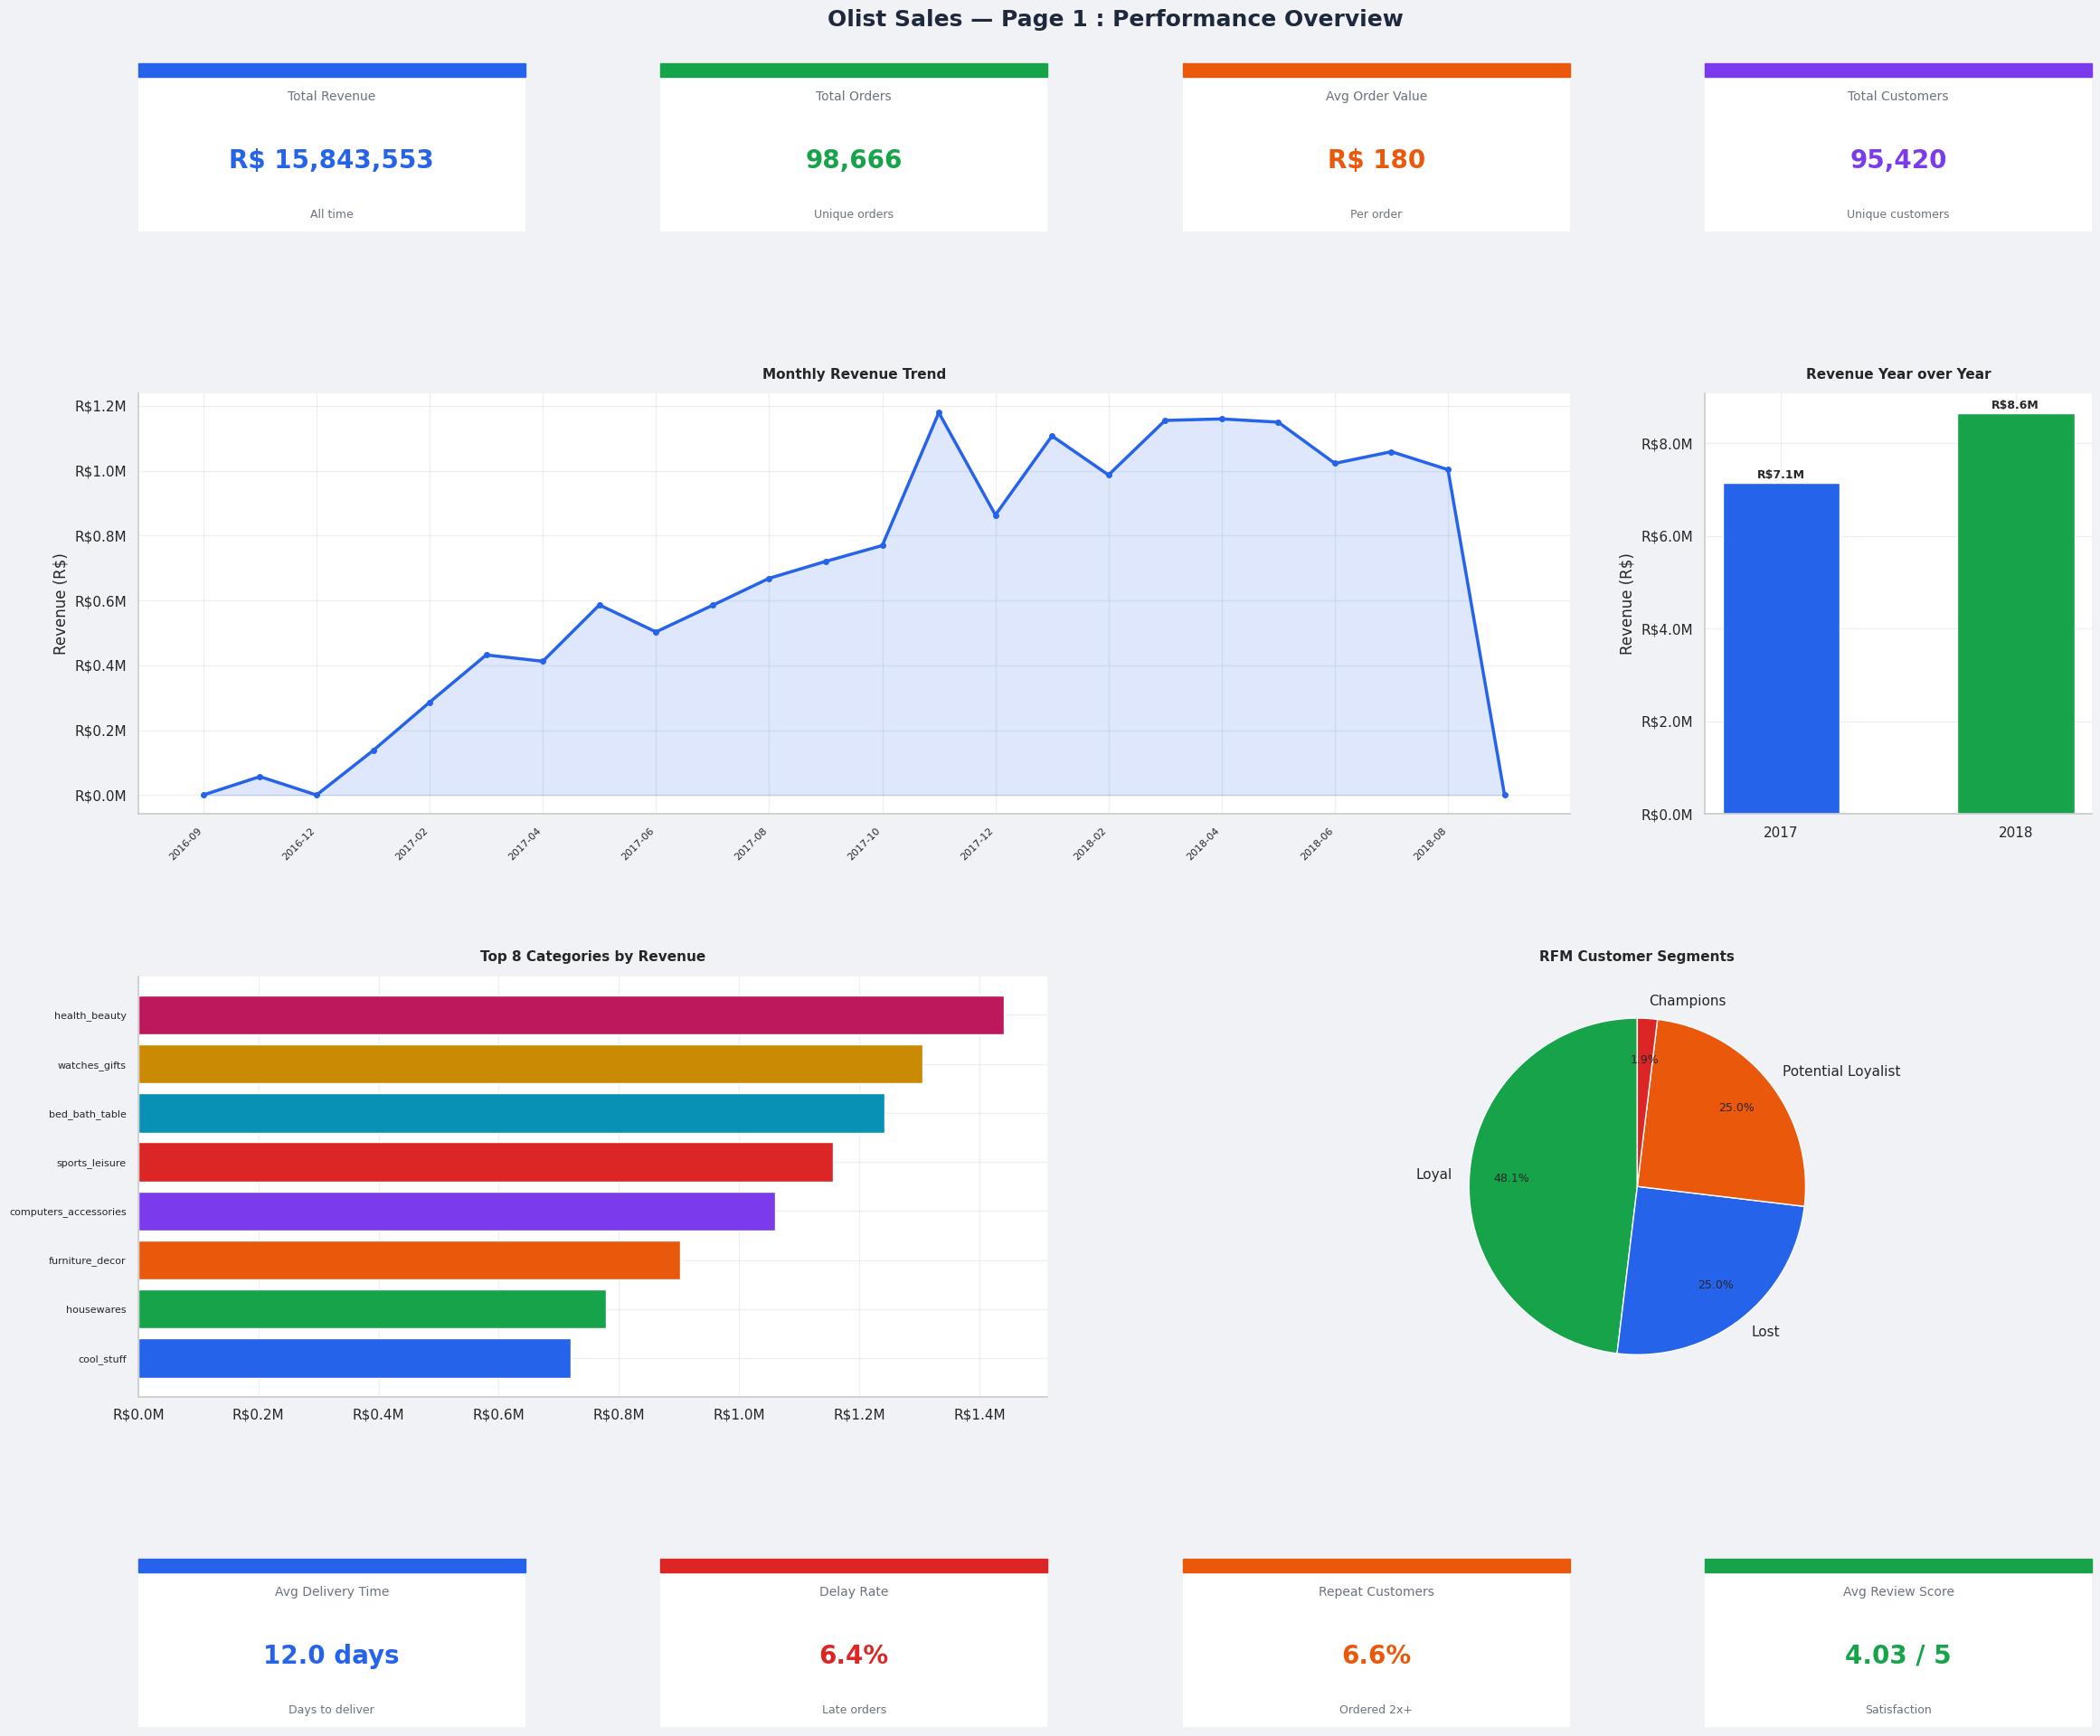

Page 1 saved : dashboard_page1.png


In [16]:
# ==========================================================
# DASHBOARD — PAGE 1 : Performance Overview
# ==========================================================

BG_COLOR   = "#f0f2f6"
CARD_COLOR = "#ffffff"
BLUE       = "#2563eb"
GREEN      = "#16a34a"
RED        = "#dc2626"
ORANGE     = "#ea580c"
PURPLE     = "#7c3aed"
GRAY       = "#6b7280"
COLORS     = [BLUE, GREEN, ORANGE, PURPLE, RED, "#0891b2", "#ca8a04", "#be185d"]

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.titlesize"   : 11,
    "axes.titleweight" : "bold",
    "axes.titlepad"    : 12,
})

# -------------------------
# KPI card helper
# -------------------------
def kpi_card(ax, title, value, subtitle="", color=BLUE):
    ax.set_facecolor(CARD_COLOR)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.80, title,    ha="center", va="center",
            fontsize=10, color=GRAY,  transform=ax.transAxes)
    ax.text(0.5, 0.42, value,    ha="center", va="center",
            fontsize=20, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.10, subtitle, ha="center", va="center",
            fontsize=9,  color=GRAY,  transform=ax.transAxes)
    ax.add_patch(plt.Rectangle(
        (0, 0.92), 1, 0.08,
        transform=ax.transAxes, color=color, clip_on=False
    ))

# -------------------------
# Figure layout
# -------------------------
fig1 = plt.figure(figsize=(24, 20), facecolor=BG_COLOR)
fig1.suptitle(
    "Olist Sales — Page 1 : Performance Overview",
    fontsize=18, fontweight="bold", y=0.98, color="#1e293b"
)

gs1 = fig1.add_gridspec(
    nrows=4, ncols=4,
    height_ratios=[1, 2.5, 2.5, 1],
    hspace=0.55, wspace=0.35,
    left=0.05, right=0.95,
    top=0.95, bottom=0.03
)

# -------------------------
# ROW 0 — KPI Cards (top 4)
# -------------------------
kpis_row0 = [
    ("Total Revenue",    f"R$ {total_revenue:,.0f}",    "All time",         BLUE),
    ("Total Orders",     f"{total_orders:,}",            "Unique orders",    GREEN),
    ("Avg Order Value",  f"R$ {avg_order_value:,.0f}",  "Per order",        ORANGE),
    ("Total Customers",  f"{total_customers:,}",         "Unique customers", PURPLE),
]

for i, (title, value, subtitle, color) in enumerate(kpis_row0):
    ax = fig1.add_subplot(gs1[0, i])
    kpi_card(ax, title, value, subtitle, color)

# -------------------------
# ROW 1 — Monthly Revenue Trend + YoY
# -------------------------
monthly = (
    df_sales.groupby("year_month")["revenue"]
    .sum().reset_index().sort_values("year_month")
)

ax1 = fig1.add_subplot(gs1[1, 0:3])
ax1.set_facecolor(CARD_COLOR)
ax1.fill_between(range(len(monthly)), monthly["revenue"],
                 alpha=0.15, color=BLUE)
ax1.plot(range(len(monthly)), monthly["revenue"],
         color=BLUE, linewidth=2.5, marker="o", markersize=4)
ax1.set_title("Monthly Revenue Trend")
ax1.set_xticks(range(0, len(monthly), 2))
ax1.set_xticklabels(monthly["year_month"].iloc[::2],
                    rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Revenue (R$)")
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

ax2 = fig1.add_subplot(gs1[1, 3])
ax2.set_facecolor(CARD_COLOR)
yoy = yearly_kpis[yearly_kpis["year"].isin([2017, 2018])]
ax2.bar(yoy["year"].astype(str), yoy["revenue"],
        color=[BLUE, GREEN], width=0.5)
ax2.set_title("Revenue Year over Year")
ax2.set_ylabel("Revenue (R$)")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
for i, (_, row) in enumerate(yoy.iterrows()):
    ax2.text(i, row["revenue"] + 100000,
             f"R${row['revenue']/1e6:.1f}M",
             ha="center", fontsize=9, fontweight="bold")

# -------------------------
# ROW 2 — Top Categories + RFM Segments
# -------------------------
top_cats = (
    df_sales.groupby("product_category_name_english")["revenue"]
    .sum().sort_values(ascending=True).tail(8)
)

ax3 = fig1.add_subplot(gs1[2, 0:2])
ax3.set_facecolor(CARD_COLOR)
ax3.barh(range(len(top_cats)), top_cats.values,
         color=COLORS[:len(top_cats)])
ax3.set_yticks(range(len(top_cats)))
ax3.set_yticklabels(top_cats.index, fontsize=8)
ax3.set_title("Top 8 Categories by Revenue")
ax3.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

# Clean RFM labels — no emojis for matplotlib
rfm_counts = rfm["segment"].value_counts()

ax4 = fig1.add_subplot(gs1[2, 2:4])
ax4.set_facecolor(CARD_COLOR)
wedges, texts, autotexts = ax4.pie(
    rfm_counts.values,
    labels=rfm_counts.index,
    autopct="%1.1f%%",
    colors=[GREEN, BLUE, ORANGE, RED],
    startangle=90,
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(9)
ax4.set_title("RFM Customer Segments")

# -------------------------
# ROW 3 — KPI Cards (bottom 4)
# -------------------------
kpis_row3 = [
    ("Avg Delivery Time", f"{avg_delivery_time:.1f} days", "Days to deliver",  BLUE),
    ("Delay Rate",        f"{delay_rate*100:.1f}%",        "Late orders",      RED),
    ("Repeat Customers",  f"{repeat_customer_rate*100:.1f}%", "Ordered 2x+",  ORANGE),
    ("Avg Review Score",  f"{avg_review_score:.2f} / 5",   "Satisfaction",     GREEN),
]

for i, (title, value, subtitle, color) in enumerate(kpis_row3):
    ax = fig1.add_subplot(gs1[3, i])
    kpi_card(ax, title, value, subtitle, color)

# -------------------------
# Save
# -------------------------
plt.savefig("dashboard_page1.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Page 1 saved : dashboard_page1.png")
#print("Seite 1 gespeichert : dashboard_page1.png")

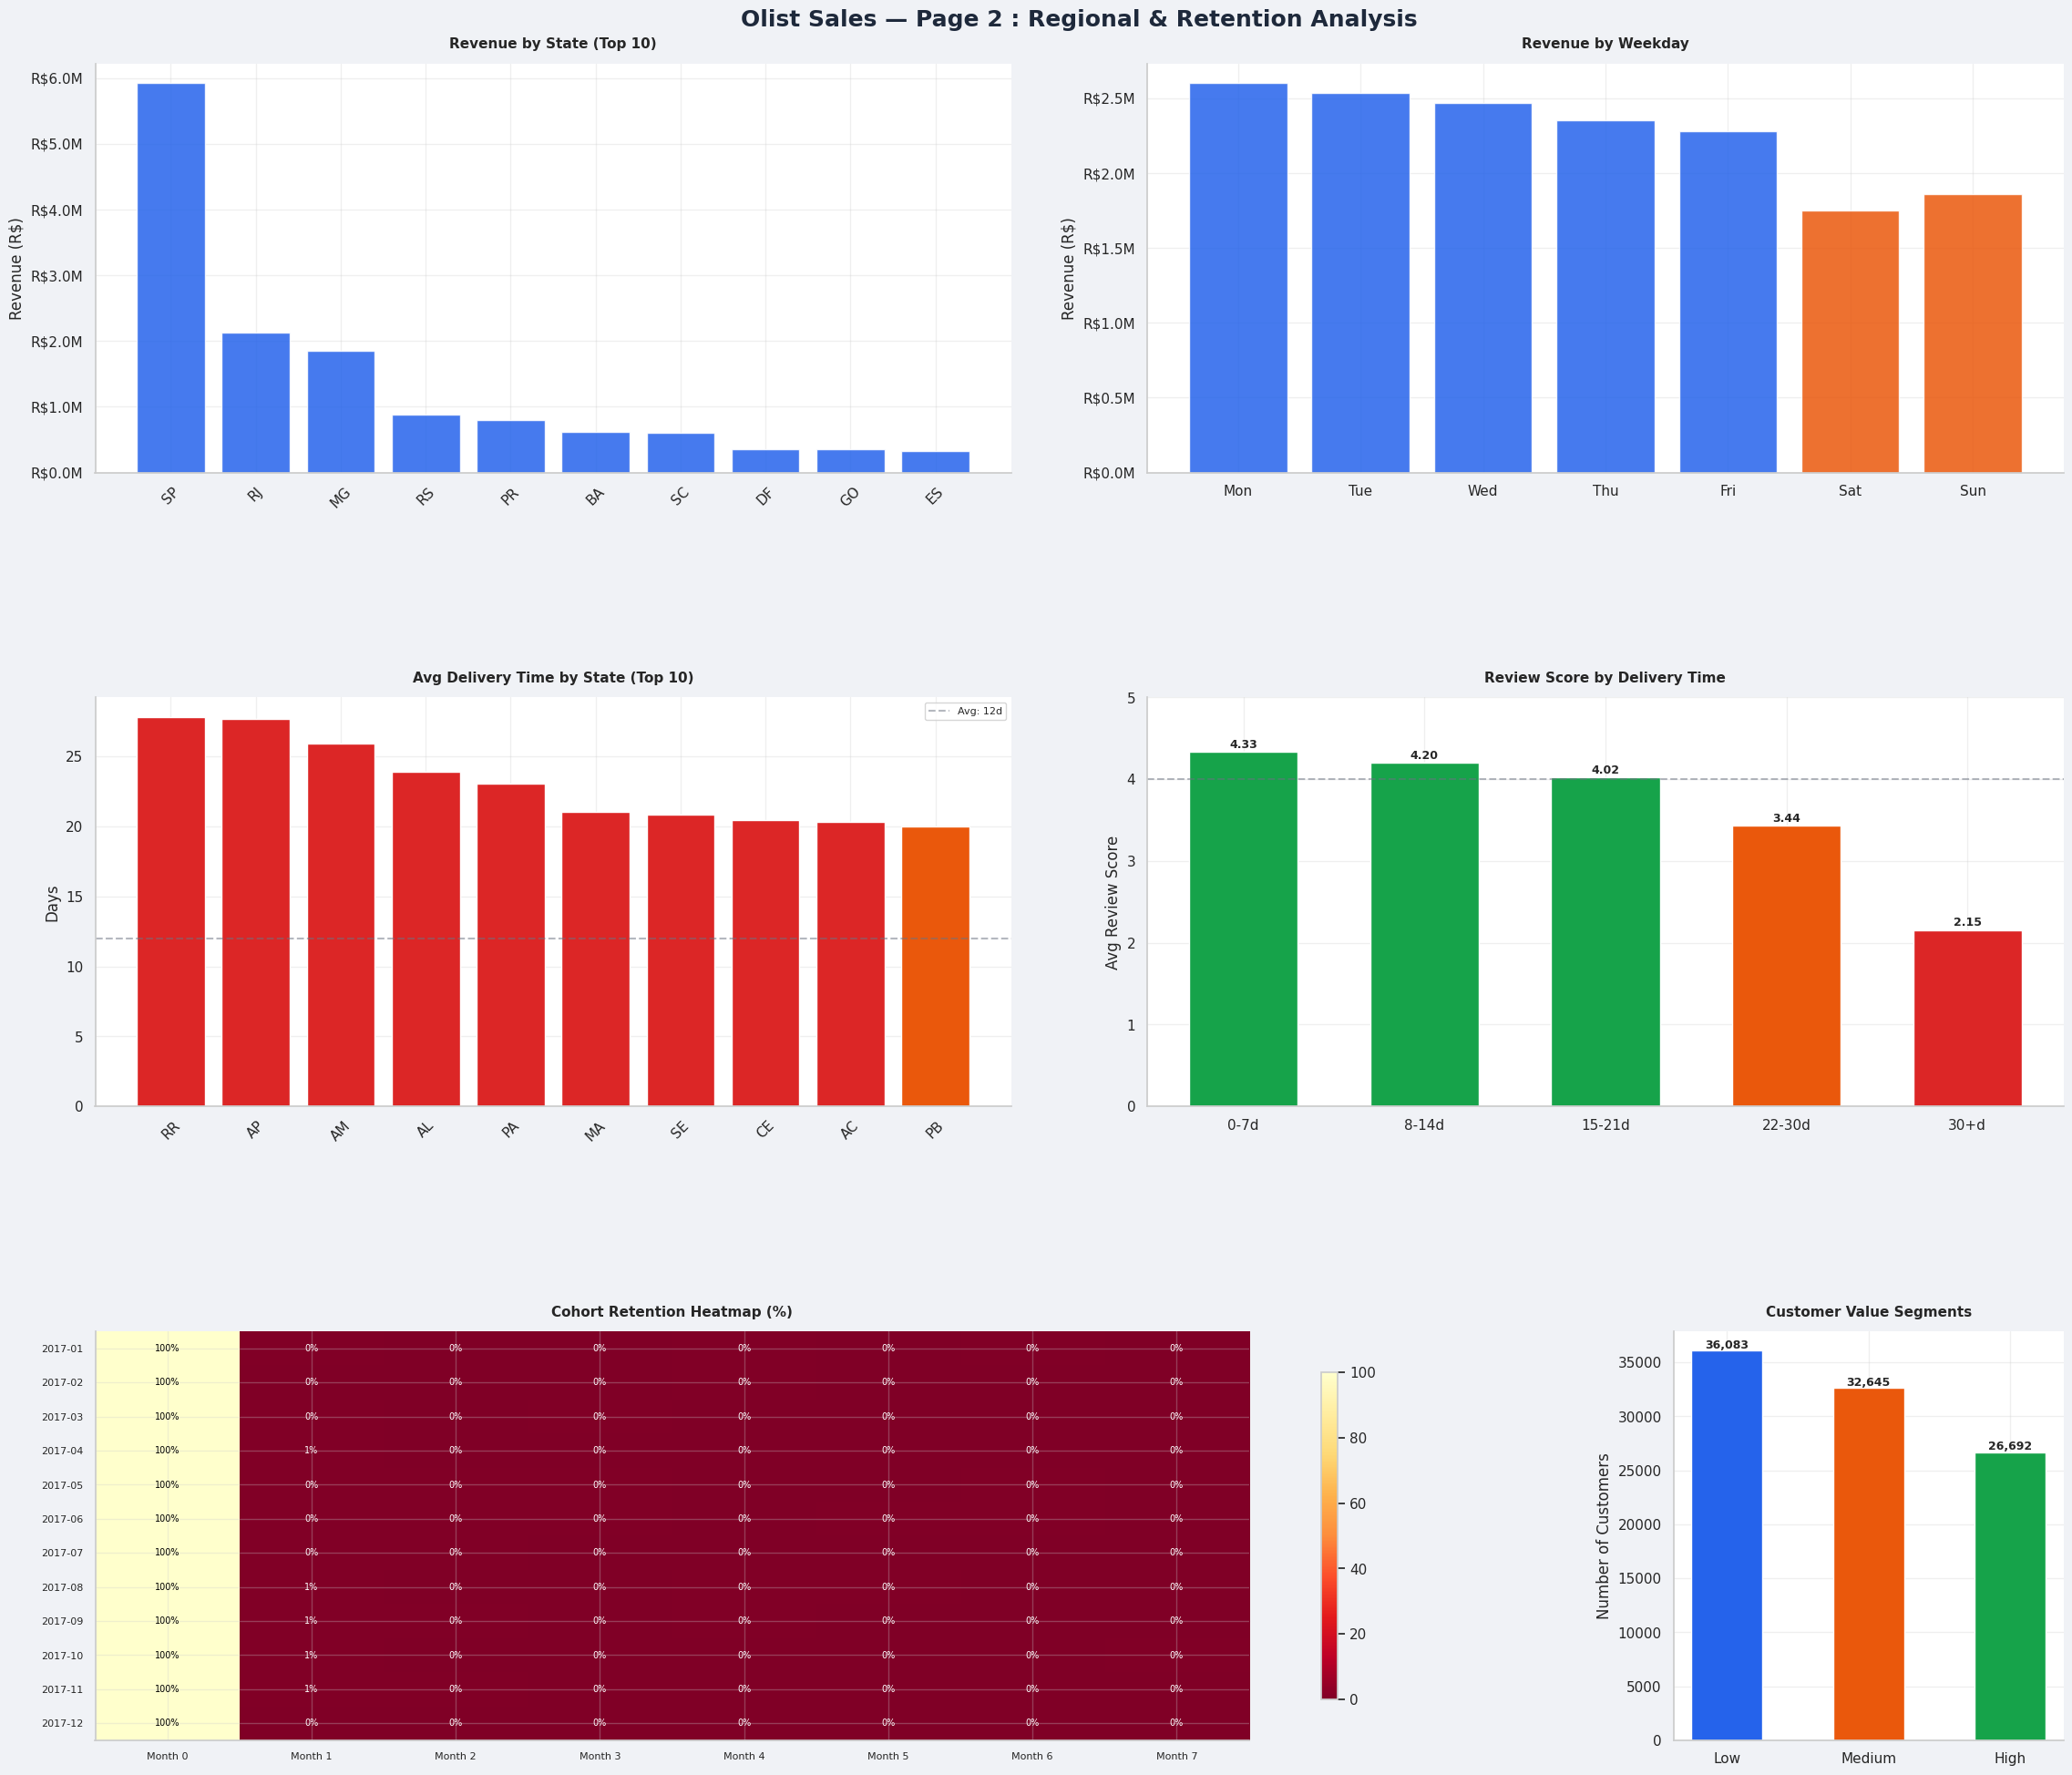

 Page 2 saved : dashboard_page2.png


In [17]:
# ==========================================================
# DASHBOARD — PAGE 2 : Regional & Retention Analysis
# ==========================================================

fig2 = plt.figure(figsize=(24, 20), facecolor=BG_COLOR)
fig2.suptitle(
    "Olist Sales — Page 2 : Regional & Retention Analysis",
    fontsize=18, fontweight="bold", y=0.98, color="#1e293b"
)

gs2 = fig2.add_gridspec(
    nrows=3, ncols=4,
    height_ratios=[2.5, 2.5, 2.5],
    hspace=0.55, wspace=0.35,
    left=0.05, right=0.95,
    top=0.95, bottom=0.03
)

# -------------------------
# ROW 0 — Revenue by State + Weekday
# -------------------------
region = (
    df_sales.groupby("customer_state")["revenue"]
    .sum().sort_values(ascending=False).head(10)
)

ax1 = fig2.add_subplot(gs2[0, 0:2])
ax1.set_facecolor(CARD_COLOR)
ax1.bar(region.index, region.values, color=BLUE, alpha=0.85)
ax1.set_title("Revenue by State (Top 10)")
ax1.set_ylabel("Revenue (R$)")
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax1.tick_params(axis="x", rotation=45)

weekday_order = ["Monday","Tuesday","Wednesday",
                 "Thursday","Friday","Saturday","Sunday"]
weekday = (
    df_sales.groupby("weekday")["revenue"]
    .sum().reindex(weekday_order)
)

ax2 = fig2.add_subplot(gs2[0, 2:4])
ax2.set_facecolor(CARD_COLOR)
ax2.bar(
    [d[:3] for d in weekday_order],
    weekday.values,
    color=[ORANGE if d in ["Saturday","Sunday"] else BLUE
           for d in weekday_order],
    alpha=0.85
)
ax2.set_title("Revenue by Weekday")
ax2.set_ylabel("Revenue (R$)")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

# -------------------------
# ROW 1 — Delivery by State + Review by Delivery
# -------------------------
delivery_state = (
    df_delivery.groupby("customer_state")["delivery_time_days"]
    .mean().sort_values(ascending=False).head(10)
)

ax3 = fig2.add_subplot(gs2[1, 0:2])
ax3.set_facecolor(CARD_COLOR)
bar_colors_d = [RED if v > 20 else ORANGE if v > 15 else GREEN
                for v in delivery_state.values]
ax3.bar(delivery_state.index, delivery_state.values, color=bar_colors_d)
ax3.axhline(y=12, color=GRAY, linestyle="--",
            alpha=0.5, label="Avg: 12d")
ax3.set_title("Avg Delivery Time by State (Top 10)")
ax3.set_ylabel("Days")
ax3.legend(fontsize=8)
ax3.tick_params(axis="x", rotation=45)

buckets = ["0-7d", "8-14d", "15-21d", "22-30d", "30+d"]
scores  = bucket_review["avg_review"].values

ax4 = fig2.add_subplot(gs2[1, 2:4])
ax4.set_facecolor(CARD_COLOR)
bar_colors_r = [GREEN if s >= 4 else ORANGE if s >= 3 else RED
                for s in scores]
bars = ax4.bar(buckets, scores, color=bar_colors_r, width=0.6)
ax4.axhline(y=4.0, color=GRAY, linestyle="--", alpha=0.5)
ax4.set_ylim(0, 5)
ax4.set_title("Review Score by Delivery Time")
ax4.set_ylabel("Avg Review Score")
for bar, score in zip(bars, scores):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{score:.2f}", ha="center",
             fontsize=9, fontweight="bold")

# -------------------------
# ROW 2 — Cohort Heatmap + Customer Segments
# -------------------------
ax5 = fig2.add_subplot(gs2[2, 0:3])
ax5.set_facecolor(CARD_COLOR)
cohort_plot = retention_table.iloc[3:15, 0:8]
im = ax5.imshow(cohort_plot.values, cmap="YlOrRd_r",
                aspect="auto", vmin=0, vmax=100)
ax5.set_xticks(range(cohort_plot.shape[1]))
ax5.set_xticklabels(
    [f"Month {i}" for i in range(cohort_plot.shape[1])],
    fontsize=8)
ax5.set_yticks(range(cohort_plot.shape[0]))
ax5.set_yticklabels(cohort_plot.index.astype(str), fontsize=8)
ax5.set_title("Cohort Retention Heatmap (%)")
for i in range(cohort_plot.shape[0]):
    for j in range(cohort_plot.shape[1]):
        val = cohort_plot.values[i, j]
        if not np.isnan(val):
            ax5.text(j, i, f"{val:.0f}%",
                    ha="center", va="center", fontsize=7,
                    color="white" if val < 50 else "black")
plt.colorbar(im, ax=ax5, shrink=0.8)

customer_seg = (
    df_sales[["customer_unique_id", "customer_segment"]]
    .drop_duplicates()
    .groupby("customer_segment")
    .size()
)

ax6 = fig2.add_subplot(gs2[2, 3])
ax6.set_facecolor(CARD_COLOR)
ax6.bar(
    customer_seg.index.astype(str),
    customer_seg.values,
    color=[BLUE, ORANGE, GREEN], width=0.5
)
ax6.set_title("Customer Value Segments")
ax6.set_ylabel("Number of Customers")
for i, (idx, val) in enumerate(customer_seg.items()):
    ax6.text(i, val + 200, f"{val:,}",
             ha="center", fontsize=9, fontweight="bold")

# -------------------------
# Save
# -------------------------
plt.savefig("dashboard_page2.png", dpi=150,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print(" Page 2 saved : dashboard_page2.png")
#print(" Seite 2 gespeichert : dashboard_page2.png")

###  Dashboard Summary

**Page 1 — Performance Overview**
| Chart | Key Finding |
|-------|-------------|
| Monthly Revenue Trend | Peak in Nov 2017 — Black Friday effect |
| Revenue YoY | +21% growth from 2017 to 2018 |
| Top 8 Categories | Health & Beauty leads revenue |
| RFM Segments | 48% Loyal, 25% Lost |

**Page 2 — Regional & Retention Analysis**
| Chart | Key Finding |
|-------|-------------|
| Revenue by State | SP dominates with 40%+ of total revenue |
| Revenue by Weekday | Weekdays outperform weekends |
| Delivery by State | Northern states 2x slower than average |
| Review by Delivery | Score drops below 3.5 after 22 days |
| Cohort Heatmap | Less than 1% retention after month 1 |
| Customer Segments | Balanced Low / Medium / High distribution |

In [20]:
# ==========================================================
# SAVE GOLD DATASET
# ==========================================================

gold_file = os.path.join(gold_path, "sales_gold.csv")

df_sales.to_csv(gold_file, index=False)

# Output / Ausgabe
print(f" Gold dataset saved successfully")
#print(f" Gold-Datensatz erfolgreich gespeichert")
print(f"\n   Path    : {gold_file}")
print(f"   Rows    : {df_sales.shape[0]:,}")
print(f"   Columns : {df_sales.shape[1]}")

 Gold dataset saved successfully

   Path    : /Users/bryolt./Desktop/Python Projects/Olist-sales-analysis/data/gold/sales_gold.csv
   Rows    : 112,650
   Columns : 54


# Machine Learning 

We build 2 predictive models using our gold dataset.

| Model | Type | Target | Question |
|-------|------|--------|----------|
| Model 1 | Classification | `is_late` | Will this order be delivered late? |
| Model 2 | Regression | `review_score` | What will the customer review score be? |

### Features used
| Feature | Description |
|---------|-------------|
| `price` | Product price |
| `freight_value` | Shipping cost |
| `freight_ratio` | Freight share of revenue |
| `items_per_order` | Number of items |
| `order_total_value` | Total order value |
| `payment_installments` | Number of installments |
| `product_weight_g` | Product weight |
| `month` | Month of purchase |
| `quarter` | Quarter of purchase |
| `customer_state` | Customer location |
| `product_category_name_english` | Product category |

In [23]:
# -------------------------
# 1. Prepare ML dataset
# -------------------------
ml_features = [
    "price", "freight_value", "freight_ratio",
    "items_per_order", "order_total_value",
    "payment_installments", "product_weight_g",
    "month", "quarter",
    "customer_state", "product_category_name_english"
]

df_ml = df_sales[ml_features + ["is_late", "review_score"]].dropna().copy()

# -------------------------
# 2. Encode categorical columns
# -------------------------
le_state    = LabelEncoder()
le_category = LabelEncoder()

df_ml["customer_state"]                  = le_state.fit_transform(df_ml["customer_state"])
df_ml["product_category_name_english"]   = le_category.fit_transform(df_ml["product_category_name_english"])

print(f" ML dataset ready")
print(f"   Rows    : {df_ml.shape[0]:,}")
print(f"   Columns : {df_ml.shape[1]}")

# -------------------------
# 3. Define X
# -------------------------
X = df_ml[ml_features]

# ==========================================================
# MODEL 1 — Classification : Predict is_late
# ==========================================================
print("\n" + "=" * 55)
print("  MODEL 1 — Late Delivery Prediction")
print("=" * 55)

y_class = df_ml["is_late"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

print(f"\nTraining samples : {X_train_c.shape[0]:,}")
print(f"Testing samples  : {X_test_c.shape[0]:,}")
print(f"\nClassification Report:")
print(classification_report(y_test_c, y_pred_c,
                            target_names=["On-time", "Late"]))

# Feature importance
feat_imp_c = pd.Series(clf.feature_importances_, index=ml_features)
feat_imp_c = feat_imp_c.sort_values(ascending=False)

print("Top 5 Features:")
print(feat_imp_c.head(5).round(3).to_string())

# ==========================================================
# MODEL 2 — Regression : Predict review_score
# ==========================================================
print("\n" + "=" * 55)
print("  MODEL 2 — Review Score Prediction")
print("=" * 55)

y_reg = df_ml["review_score"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_train_r, y_train_r)

y_pred_r = reg.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)

print(f"\nTraining samples : {X_train_r.shape[0]:,}")
print(f"Testing samples  : {X_test_r.shape[0]:,}")
print(f"\nMean Absolute Error (MAE) : {mae:.3f}")
print(f"R² Score                  : {r2:.3f}")

# Feature importance
feat_imp_r = pd.Series(reg.feature_importances_, index=ml_features)
feat_imp_r = feat_imp_r.sort_values(ascending=False)

print("\nTop 5 Features:")
print(feat_imp_r.head(5).round(3).to_string())

 ML dataset ready
   Rows    : 110,092
   Columns : 13

  MODEL 1 — Late Delivery Prediction

Training samples : 88,073
Testing samples  : 22,019

Classification Report:
              precision    recall  f1-score   support

     On-time       0.95      0.99      0.97     20622
        Late       0.62      0.16      0.26      1397

    accuracy                           0.94     22019
   macro avg       0.78      0.58      0.61     22019
weighted avg       0.93      0.94      0.92     22019

Top 5 Features:
order_total_value   0.15
freight_ratio       0.14
freight_value       0.13
product_weight_g    0.13
price               0.13

  MODEL 2 — Review Score Prediction

Training samples : 88,073
Testing samples  : 22,019

Mean Absolute Error (MAE) : 0.951
R² Score                  : 0.183

Top 5 Features:
product_weight_g    0.15
freight_ratio       0.14
freight_value       0.14
order_total_value   0.13
price               0.10


### Results

#### Model 1 — Late Delivery Prediction (Classification)

| Metric | On-time | Late |
|--------|---------|------|
| Precision | 95% | 62% |
| Recall | 99% | 16% |
| F1-Score | 97% | 26% |
| **Accuracy** | **94%** | |

**Top Features:**
| Feature | Importance |
|---------|------------|
| `order_total_value` | 15% |
| `freight_ratio` | 14% |
| `freight_value` | 13% |
| `product_weight_g` | 13% |
| `price` | 13% |

> 💡 **Interpretation:**
> - Model predicts **on-time orders very well (99% recall)**
> - Late orders are harder to predict (16% recall) — 
> dataset is **imbalanced** (only 6.4% late orders)
> - **Freight and weight are the strongest predictors** —
> heavier and more expensive shipments are more likely to be late

---

#### Model 2 — Review Score Prediction (Regression)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MAE | 0.951 | Predictions off by ~1 point on average |
| R² Score | 0.183 | Model explains 18% of variance |

> 💡 **Interpretation:**
> - R² of 0.183 is **low but expected** — review scores depend heavily 
> on subjective factors (product quality, customer expectations) 
> that are not in our dataset
> - **To improve:** add delivery delay as a feature — 
> we proved it has a -0.30 correlation with review score
> - MAE of 0.951 on a 1-5 scale means predictions are 
> roughly **within 1 star** of the actual score

##  Insights & Business Recommendations

###  Key Findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | Revenue grew **+21%** from 2017 to 2018 | KPI Analysis |
| 2 | **48% of customers are Loyal** but only 6.6% reorder | RFM + KPI |
| 3 | **25% of customers are Lost** — never came back | RFM Analysis |
| 4 | Late orders score **1.95 points lower** than on-time | Delivery Analysis |
| 5 | Review score drops **below 3.5 after 22 days** delivery | Delivery Analysis |
| 6 | **SP generates 40%+ of total revenue** | Regional Analysis |
| 7 | Northern states take **2x longer** to deliver | Regional Analysis |
| 8 | **AL and MA** have highest delay rates (20%, 18%) | Regional Analysis |
| 9 | Weekdays outperform weekends in revenue | Dashboard |
| 10 | Freight and weight are the **#1 predictors of late delivery** | ML Model 1 |

---

###  Business Recommendations

#### 1. Improve Customer Retention
> **Problem:** 6.6% repeat rate — 25% of customers are Lost
- Launch **post-purchase email campaigns** 7 days after delivery
- Implement a **loyalty rewards program** for repeat customers
- Target **Potential Loyalists** (25%) with personalized discounts

#### 2. Fix Logistics in High-Delay Regions
> **Problem:** AL (20%) and MA (18%) have critical delay rates
- Negotiate **dedicated logistics partnerships** in AL and MA
- Set up **regional warehouses** in the Northeast to reduce transit time
- Monitor shipments with **automated delay alerts**

#### 3. Reduce Delivery Time to Boost Satisfaction
> **Problem:** Score drops below 3.5 after 22 days
- Set internal target : **deliver in under 14 days**
- Prioritize **heavy products** (top predictor of late delivery)
- Offer **real-time tracking** to manage customer expectations

#### 4. Capitalize on High-Value Segments
> **Problem:** Champions are only 1.9% of customers
- Create a **VIP program** for Champions and High-value customers
- Offer **exclusive deals** to Medium segment to move them to High
- Analyze Champions' purchasing behavior to replicate it

#### 5. Expand in High-Revenue States
> **Opportunity:** SP dominates — other states are underserved
- Invest in **marketing campaigns** in RJ, MG, RS
- Offer **reduced freight** for underserved Northern states
- Partner with **local sellers** in low-revenue states

---

###  Conclusion

> Olist is a **fast-growing platform** with strong revenue trends.
> The main challenges are **customer retention** and **logistics performance**
> — both directly impact customer satisfaction and long-term growth.
> Addressing these two areas could unlock significant revenue potential.

##  Erkenntnisse & Geschäftsempfehlungen

###  Wichtigste Erkenntnisse

| # | Erkenntnis | Quelle |
|---|-----------|--------|
| 1 | Umsatz wuchs **+21%** von 2017 auf 2018 | KPI-Analyse |
| 2 | **48% der Kunden sind loyal**, aber nur 6,6% bestellen erneut | RFM + KPI |
| 3 | **25% der Kunden sind verloren** — kamen nie zurück | RFM-Analyse |
| 4 | Verspätete Bestellungen erhalten **1,95 Punkte weniger** | Lieferanalyse |
| 5 | Bewertung fällt **unter 3,5 nach 22 Tagen** Lieferzeit | Lieferanalyse |
| 6 | **SP generiert 40%+ des Gesamtumsatzes** | Regionalanalyse |
| 7 | Nördliche Bundesstaaten brauchen **2x länger** für Lieferungen | Regionalanalyse |
| 8 | **AL und MA** haben die höchsten Verzögerungsraten (20%, 18%) | Regionalanalyse |
| 9 | Wochentage übertreffen Wochenenden beim Umsatz | Dashboard |
| 10 | Frachtkosten und Gewicht sind die **stärksten Prädiktoren** für Verspätungen | ML Modell 1 |

---

###  Geschäftsempfehlungen

#### 1. Kundenbindung verbessern
> **Problem:** 6,6% Wiederkaufrate — 25% der Kunden sind verloren
- **E-Mail-Kampagnen** 7 Tage nach der Lieferung starten
- Ein **Treueprämienprogramm** für Stammkunden einführen
- **Potenzielle Treukunden** (25%) mit personalisierten Rabatten ansprechen

#### 2. Logistik in Regionen mit hohen Verzögerungen verbessern
> **Problem:** AL (20%) und MA (18%) haben kritische Verzögerungsraten
- **Dedizierte Logistikpartnerschaften** in AL und MA aushandeln
- **Regionale Lagerhäuser** im Nordosten einrichten
- Sendungen mit **automatischen Verzögerungswarnungen** überwachen

#### 3. Lieferzeit reduzieren für höhere Kundenzufriedenheit
> **Problem:** Bewertung fällt unter 3,5 nach 22 Tagen
- Internes Ziel setzen : **Lieferung in unter 14 Tagen**
- **Schwere Produkte** priorisieren (stärkster Prädiktor für Verspätungen)
- **Echtzeit-Tracking** anbieten um Kundenerwartungen zu steuern

#### 4. Hochwertige Kundensegmente ausschöpfen
> **Problem:** Champions sind nur 1,9% der Kunden
- Ein **VIP-Programm** für Champions und High-Value-Kunden erstellen
- **Exklusive Angebote** für das mittlere Segment anbieten
- Kaufverhalten der Champions analysieren und replizieren

#### 5. In umsatzstarken Bundesstaaten expandieren
> **Chance:** SP dominiert — andere Bundesstaaten sind unterversorgt
- In **Marketingkampagnen** in RJ, MG, RS investieren
- **Reduzierte Frachtkosten** für unterversorgte Nordstaaten anbieten
- Mit **lokalen Verkäufern** in umsatzschwachen Bundesstaaten kooperieren

---

###  Fazit

> Olist ist eine **schnell wachsende Plattform** mit starken Umsatztrends.
> Die größten Herausforderungen sind **Kundenbindung** und **Logistikleistung**
> — beide wirken sich direkt auf die Kundenzufriedenheit aus.
> Die Behebung dieser zwei Bereiche könnte erhebliches Umsatzpotenzial freisetzen.